In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

In [2]:
dt_clf = DecisionTreeClassifier(random_state=156)

iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris_data.data,
    iris_data.target,
    test_size=0.2,
    random_state=11
)

In [3]:
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

In [4]:
from sklearn.tree import export_graphviz

export_graphviz(
    dt_clf,
    out_file="tree.dot",
    class_names=iris_data.target_names,
    feature_names=iris_data.feature_names,
    impurity=True,
    filled=True
)

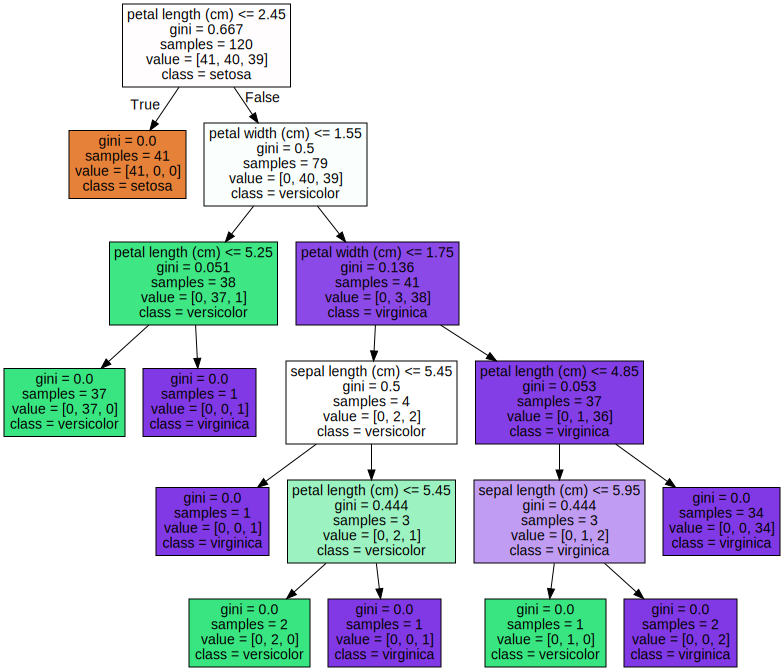

In [5]:
import graphviz

with open("tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

In [6]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print("Feature importances:\n{0}".format(
    np.round(dt_clf.feature_importances_, 3)
))

Feature importances:
[0.025 0.    0.555 0.42 ]


In [7]:
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print('{0} : {1:.3f}'.format(name, value))

sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


<Axes: >

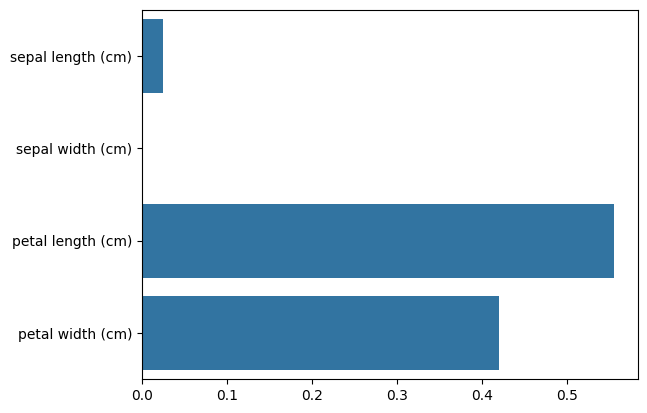

In [8]:
sns.barplot(
    x=dt_clf.feature_importances_,
    y=iris_data.feature_names
)

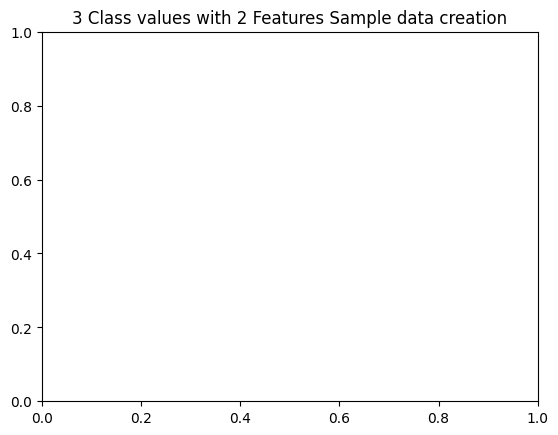

In [9]:
from sklearn.datasets import make_classification

plt.title("3 Class values with 2 Features Sample data creation")

X_features, y_labels = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=0
)

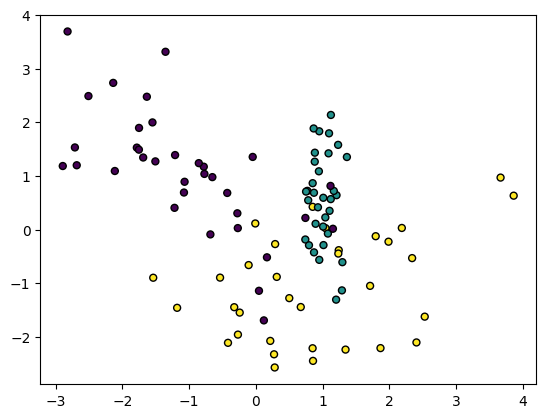

In [10]:
plt.scatter(
    X_features[:,0],
    X_features[:,1],
    marker='o',
    c=y_labels,
    s=25,
    edgecolor='k'
)

In [11]:
from matplotlib.colors import ListedColormap

def visualize_boundary(model, X, y):

    cmap_light = ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF'])

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        s=20,
        edgecolor='k'
    )

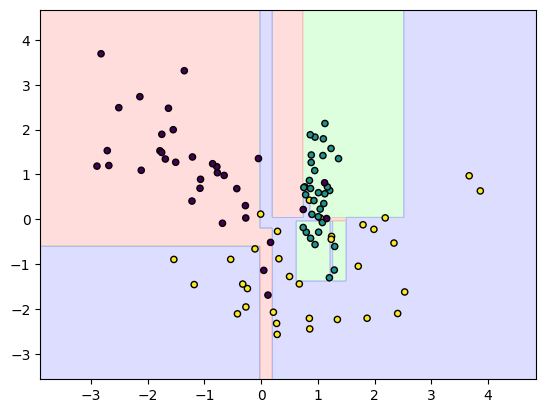

In [12]:
dt_clf = DecisionTreeClassifier(random_state=156).fit(X_features, y_labels)

visualize_boundary(dt_clf, X_features, y_labels)

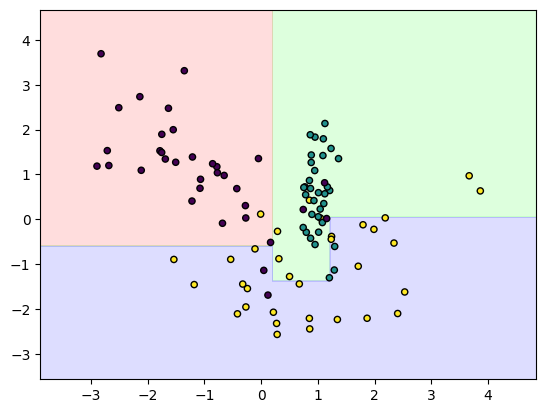

In [13]:
dt_clf = DecisionTreeClassifier(
    min_samples_leaf=6,
    random_state=156
).fit(X_features, y_labels)

visualize_boundary(dt_clf, X_features, y_labels)

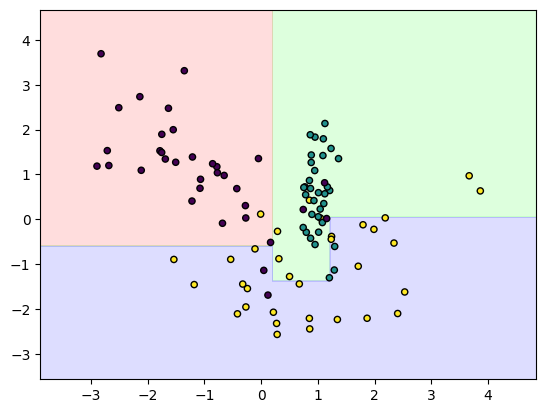

In [14]:
dt_clf = DecisionTreeClassifier(
    min_samples_leaf=6,
    random_state=156
).fit(X_features, y_labels)

visualize_boundary(dt_clf, X_features, y_labels)

In [24]:
from google.colab import files
uploaded = files.upload()

Saving activity_labels.txt to activity_labels.txt
Saving features.txt to features (1).txt


In [27]:
import pandas as pd

feature_name_df = pd.read_csv(
    './features.txt',
    sep='\s+',
    header=None,
    names=['column_index','column_name']
)

In [28]:
feature_name = feature_name_df.iloc[:,1].values.tolist()

print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [29]:
feature_dup_df = feature_name_df.groupby('column_name').count()

print(feature_dup_df[feature_dup_df['column_index'] > 1].count())

feature_dup_df[feature_dup_df['column_index'] > 1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [30]:
def get_new_feature_name_df(old_feature_name_df):

    feature_dup_df = pd.DataFrame(
        data=old_feature_name_df.groupby('column_name').cumcount(),
        columns=['dup_cnt']
    )

    feature_dup_df = feature_dup_df.reset_index()

    new_feature_name_df = pd.merge(
        old_feature_name_df.reset_index(),
        feature_dup_df,
        how='outer'
    )

    new_feature_name_df['column_name'] = new_feature_name_df[
        ['column_name','dup_cnt']
    ].apply(
        lambda x: x[0]+'_'+str(x[1]) if x[1] > 0 else x[0],
        axis=1
    )

    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)

    return new_feature_name_df

In [33]:
from google.colab import files
uploaded = files.upload()

Saving subject_train.txt to subject_train.txt
Saving X_train.txt to X_train.txt
Saving y_train.txt to y_train.txt


In [36]:
def get_human_dataset():

    feature_name_df = pd.read_csv(
        './features.txt',
        sep='\s+',
        header=None,
        names=['column_index','column_name']
    )

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:,1].values.tolist()

    X_train = pd.read_csv(
        './X_train.txt', # Corrected path
        sep='\s+',
        names=feature_name
    )

    X_test = pd.read_csv(
        './X_test.txt', # Corrected path, but X_test.txt is not yet uploaded
        sep='\s+',
        names=feature_name
    )

    y_train = pd.read_csv(
        './y_train.txt', # Corrected path
        sep='\s+',
        header=None,
        names=['action']
    )

    y_test = pd.read_csv(
        './y_test.txt', # Corrected path, but y_test.txt is not yet uploaded
        sep='\s+',
        header=None,
        names=['action']
    )

    return X_train, X_test, y_train, y_test

In [37]:
from google.colab import files
uploaded = files.upload()

Saving X_test.txt to X_test.txt
Saving y_test.txt to y_test.txt


In [38]:
X_train, X_test, y_train, y_test = get_human_dataset()

In [39]:
print("## 학습 피처 데이터셋 info")
print(X_train.info())

## 학습 피처 데이터셋 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [40]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [41]:
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=156)

dt_clf.fit(X_train, y_train)

pred = dt_clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.8548


In [45]:
print('DecisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

DecisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


In [47]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[6,8,10,12,16,20,24],
    'min_samples_split':[16]
}

grid_cv = GridSearchCV(
    dt_clf,
    param_grid=params,
    scoring='accuracy',
    cv=5,
    verbose=1
)

grid_cv.fit(X_train, y_train)

print('GridSearchCV 최고 평균 정확도:', grid_cv.best_score_)

print('최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도: 0.8548794147162603
최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [48]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[['param_max_depth','mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


In [49]:
max_depths = [6,8,10,12,16,20,24]

for depth in max_depths:

    dt_clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=16,
        random_state=156
    )

    dt_clf.fit(X_train, y_train)

    pred = dt_clf.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    print('max_depth = {0} 정확도: {1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도: 0.8551
max_depth = 8 정확도: 0.8717
max_depth = 10 정확도: 0.8599
max_depth = 12 정확도: 0.8571
max_depth = 16 정확도: 0.8599
max_depth = 20 정확도: 0.8565
max_depth = 24 정확도: 0.8565


In [50]:
params = {
    'max_depth':[8,12,16,20],
    'min_samples_split':[16,24]
}

grid_cv = GridSearchCV(
    dt_clf,
    param_grid=params,
    scoring='accuracy',
    cv=5,
    verbose=1
)

grid_cv.fit(X_train, y_train)

print('GridSearchCV 최고 평균 정확도:', grid_cv.best_score_)

print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도: 0.8548794147162603
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [51]:
best_df_clf = grid_cv.best_estimator_

pred = best_df_clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print('결정 트리 예측 정확도:', accuracy)

결정 트리 예측 정확도: 0.8717339667458432


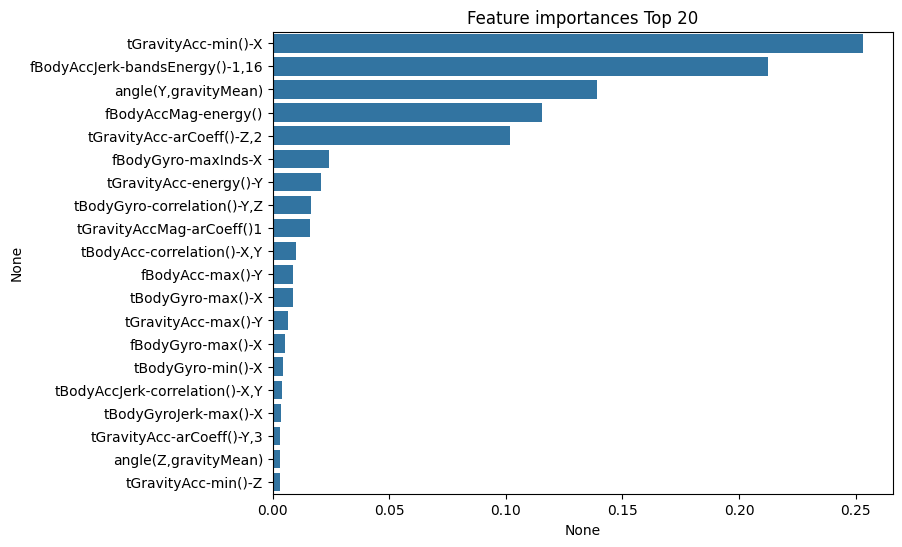

In [52]:
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_

ftr_importances = pd.Series(
    ftr_importances_values,
    index=X_train.columns
)

ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))

plt.title('Feature importances Top 20')

sns.barplot(
    x=ftr_top20,
    y=ftr_top20.index
)

plt.show()

In [53]:
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [54]:
# 개별 모델 생성
lr_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 소프트 보팅 기반 앙상블 모델
vo_clf = VotingClassifier(
    estimators=[('LR', lr_clf), ('KNN', knn_clf)],
    voting='soft'
)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.2,
    random_state=156
)

# 학습 / 예측 / 평가
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)

print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

Voting 분류기 정확도: 0.9561


In [55]:
classifiers = [lr_clf, knn_clf]

for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)

    class_name = classifier.__class__.__name__

    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# 이전에 만든 함수 사용
X_train, X_test, y_train, y_test = get_human_dataset()

rf_clf = RandomForestClassifier(random_state=0, max_depth=8)

rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9220


In [57]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [8, 16, 24],
    'min_samples_leaf': [1, 6, 12],
    'min_samples_split': [2, 8, 16]
}

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
    n_jobs=-1
)

grid_cv = GridSearchCV(
    rf_clf,
    param_grid=params,
    cv=2,
    n_jobs=-1
)

grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 16, 'min_samples_leaf': 6, 'min_samples_split': 16}
최고 예측 정확도: 0.9157


In [58]:
rf_clf1 = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=6,
    max_depth=16,
    min_samples_split=2,
    random_state=0
)

rf_clf1.fit(X_train, y_train)

pred = rf_clf1.predict(X_test)

print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9253


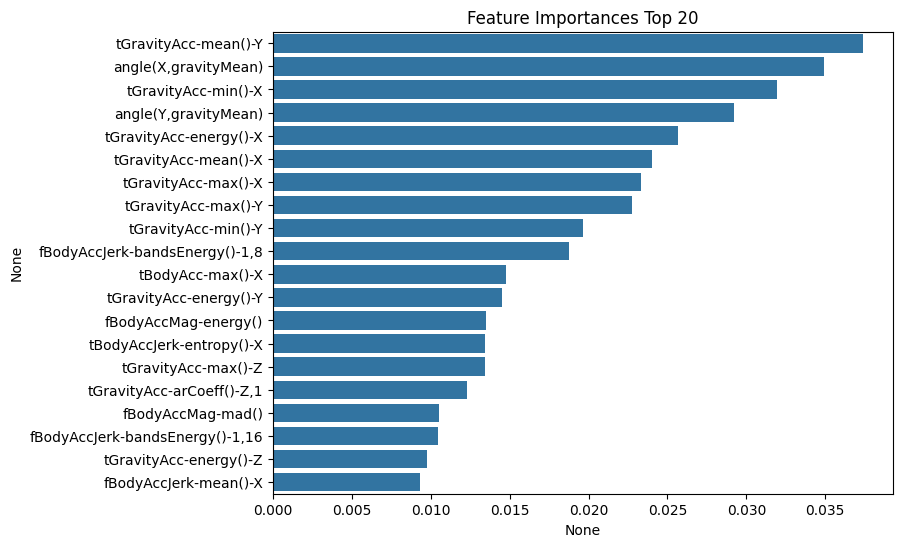

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_

ftr_importances = pd.Series(
    ftr_importances_values,
    index=X_train.columns
)

ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8, 6))
plt.title('Feature Importances Top 20')

sns.barplot(
    x=ftr_top20,
    y=ftr_top20.index
)

plt.show()